# 06 — Semantic topic analysis

In [8]:
import os
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
try:
    from IPython.display import display
except ImportError:
    def display(value):
        if hasattr(value, "to_string"):
            print(value.to_string(index=False))
        else:
            print(value)

ANALYSIS_YEARS = [2024, 2025]
EXPECTED_PAPERS = 43_370

# Set this single switch to True to reproduce every computational stage
# from the paper/abstract inputs. False reuses the verified intermediate
# files distributed with the repository.
RUN_FROM_SCRATCH = False
REBUILD_FILTERED_CORPUS = RUN_FROM_SCRATCH
REGENERATE_EMBEDDINGS = RUN_FROM_SCRATCH
RUN_K_SCAN = RUN_FROM_SCRATCH
RUN_FINAL_CLUSTERING = RUN_FROM_SCRATCH

# Restrict embedding generation to one GPU and cap CPU thread usage.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "8")
os.environ.setdefault("OMP_NUM_THREADS", "8")
os.environ.setdefault("MKL_NUM_THREADS", "8")

search_roots = [Path.cwd(), *Path.cwd().parents]
REPO_ROOT = next(
    (
        root
        for root in search_roots
        if (root / "data" / "processed" / "id_papers.csv").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/processed/id_papers.csv from the current directory."
    )

PROCESSED_DATA_DIR = REPO_ROOT / "data" / "processed"
PAPERS_CSV = REPO_ROOT / "data" / "processed" / "id_papers.csv"
ALL_ABSTRACTS_CSV = REPO_ROOT / "data" / "processed" / "paper_abstracts.csv"

# Migration-only fallback to the original project files on this server.
# A standalone release should place the same files under
# data/processed/topic_analysis/.
LEGACY_DATA_DIR = Path(os.environ.get(
    "LEGACY_TOPIC_DATA_DIR",
    "/home/user/GSK/lily/science_of_science/NewDataset/"
    "AI_impact_on_cs_publications/Data",
))
LEGACY_FILTERED_CORPUS_CSV = LEGACY_DATA_DIR / "2024_2025_abstract_finetuned.csv"
LEGACY_EMBEDDING_NPY = LEGACY_DATA_DIR / "embeddings_2024_2025_bge_large_en_v1_5.npy"
LEGACY_EMBEDDING_IDS_NPY = LEGACY_DATA_DIR / "embeddings_2024_2025_bge_large_en_v1_5_ids.npy"
print(f"Repository root: {REPO_ROOT}")
print(f"Paper metadata: {PAPERS_CSV}")
print(f"Processed-data root: {PROCESSED_DATA_DIR}")
print("Reconstruction flags:", {
    "run_from_scratch": RUN_FROM_SCRATCH,
    "filtered_corpus": REBUILD_FILTERED_CORPUS,
    "embeddings": REGENERATE_EMBEDDINGS,
    "k_scan": RUN_K_SCAN,
    "final_clustering": RUN_FINAL_CLUSTERING,
})

Repository root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub
Paper metadata: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/id_papers.csv
Processed-data root: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed
Reconstruction flags: {'run_from_scratch': False, 'filtered_corpus': False, 'embeddings': False, 'k_scan': False, 'final_clustering': False}


## Select the 2024–2025 abstract corpus


In [9]:
if REBUILD_FILTERED_CORPUS:
    filtered_corpus_csv = (
        PROCESSED_DATA_DIR / "topic_analysis" / "abstracts_2024_2025.csv"
    )
    if not ALL_ABSTRACTS_CSV.exists():
        raise FileNotFoundError(
            f"Missing abstract lookup: {ALL_ABSTRACTS_CSV}. "
            "Provide columns id and abstract before rebuilding."
        )
    metadata_columns = [
        "id", "doi", "title", "Conference", "Year",
        "finetuned_decision", "finetuned_gpt_prob", "finetuned_hum_prob",
    ]
    metadata = pd.read_csv(
        PAPERS_CSV,
        usecols=metadata_columns,
        encoding="utf-8-sig",
        low_memory=False,
    )
    metadata["Year"] = pd.to_numeric(metadata["Year"], errors="coerce")
    metadata["finetuned_decision"] = pd.to_numeric(
        metadata["finetuned_decision"], errors="coerce"
    )
    metadata = metadata.loc[
        metadata["Year"].isin(ANALYSIS_YEARS)
        & metadata["finetuned_decision"].isin([0, 1])
    ].copy()
    if metadata["id"].duplicated().any():
        raise ValueError("Filtered metadata contains duplicate paper IDs.")

    abstract_lookup = pd.read_csv(
        ALL_ABSTRACTS_CSV,
        usecols=["id", "abstract"],
        encoding="utf-8-sig",
        low_memory=False,
    )
    abstract_lookup["abstract"] = (
        abstract_lookup["abstract"]
        .astype("string")
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    abstract_lookup["_has_abstract"] = (
        abstract_lookup["abstract"].notna()
        & abstract_lookup["abstract"].ne("")
    )
    abstract_lookup = (
        abstract_lookup.sort_values(
            ["id", "_has_abstract"], ascending=[True, False]
        )
        .drop_duplicates("id", keep="first")
        .drop(columns="_has_abstract")
    )
    corpus = metadata.merge(
        abstract_lookup, on="id", how="left", validate="one_to_one"
    )
    corpus = corpus.loc[
        corpus["abstract"].notna() & corpus["abstract"].ne("")
    ].reset_index(drop=True)
    if len(corpus) != EXPECTED_PAPERS:
        raise ValueError(
            f"Expected {EXPECTED_PAPERS:,} usable abstracts, found {len(corpus):,}."
        )
    filtered_corpus_csv.parent.mkdir(parents=True, exist_ok=True)
    corpus.to_csv(
        filtered_corpus_csv, index=False, encoding="utf-8-sig"
    )
    print(f"Rebuilt filtered corpus: {filtered_corpus_csv}")
    print(corpus.groupby("Year").size().rename("n_papers").to_string())
else:
    filtered_corpus_csv = (
        PROCESSED_DATA_DIR / "topic_analysis" / "abstracts_2024_2025.csv"
    )
    available_corpus = (
        filtered_corpus_csv
        if filtered_corpus_csv.exists()
        else LEGACY_FILTERED_CORPUS_CSV
    )
    print("[SKIP] 2024–2025 corpus reconstruction is disabled.")
    print(f"Available filtered corpus for optional rebuilds: {available_corpus}")

[SKIP] 2024–2025 corpus reconstruction is disabled.
Available filtered corpus for optional rebuilds: /home/user/GSK/lily/science_of_science/NewDataset/AI_impact_on_cs_publications/Data/2024_2025_abstract_finetuned.csv


# Generate BGE abstract embeddings


In [10]:
filtered_corpus_csv = (
    PROCESSED_DATA_DIR / "topic_analysis" / "abstracts_2024_2025.csv"
)
embedding_npy = (
    PROCESSED_DATA_DIR
    / "topic_analysis"
    / "embeddings_2024_2025_bge_large_en_v1_5.npy"
)
embedding_ids_npy = (
    PROCESSED_DATA_DIR
    / "topic_analysis"
    / "embeddings_2024_2025_bge_large_en_v1_5_ids.npy"
)
embedding_corpus_path = (
    filtered_corpus_csv
    if filtered_corpus_csv.exists()
    else LEGACY_FILTERED_CORPUS_CSV
)
existing_embedding_path = (
    embedding_npy if embedding_npy.exists() else LEGACY_EMBEDDING_NPY
)
existing_embedding_ids_path = (
    embedding_ids_npy
    if embedding_ids_npy.exists()
    else LEGACY_EMBEDDING_IDS_NPY
)

if REGENERATE_EMBEDDINGS:
    if not embedding_corpus_path.exists():
        raise FileNotFoundError(
            "No filtered abstract corpus is available for embedding."
        )
    import torch
    from sentence_transformers import SentenceTransformer

    embedding_corpus = pd.read_csv(
        embedding_corpus_path, encoding="utf-8-sig", low_memory=False
    )
    if embedding_corpus["id"].duplicated().any():
        raise ValueError("Embedding corpus contains duplicate paper IDs.")
    device = "cuda:0" if torch.cuda.is_available() else "cpu"
    model = SentenceTransformer("BAAI/bge-large-en-v1.5", device=device)
    embedding_matrix = model.encode(
        embedding_corpus["abstract"].astype(str).tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    ).astype(np.float32)
    if embedding_matrix.shape != (len(embedding_corpus), 1024):
        raise ValueError(
            f"Unexpected embedding shape: {embedding_matrix.shape}"
        )
    embedding_npy.parent.mkdir(parents=True, exist_ok=True)
    np.save(embedding_npy, embedding_matrix)
    np.save(
        embedding_ids_npy,
        embedding_corpus["id"].astype(str).to_numpy(dtype=str),
    )
    existing_embedding_path = embedding_npy
    existing_embedding_ids_path = embedding_ids_npy
    print(f"Generated embeddings on {device}: {embedding_matrix.shape}")
else:
    print("[SKIP] Embedding generation is disabled.")

if existing_embedding_path.exists() and existing_embedding_ids_path.exists():
    embedding_shape = np.load(
        existing_embedding_path, mmap_mode="r"
    ).shape
    embedding_id_count = len(
        np.load(existing_embedding_ids_path, allow_pickle=False)
    )
    print(f"Available embedding file: {existing_embedding_path}")
    print(f"Embedding shape: {embedding_shape}; ID count: {embedding_id_count:,}")
else:
    print("No reusable embedding files were found.")

[SKIP] Embedding generation is disabled.
Available embedding file: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/topic_analysis/embeddings_2024_2025_bge_large_en_v1_5.npy
Embedding shape: (43370, 1024); ID count: 43,370


# Scan candidate topic resolutions

Reusing candidate-K diagnostics: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/topic_analysis/kmeans_resolution_scan.csv


,representation,k,inertia,silhouette_cosine,seed_ari_42_43,min_cluster_n,p10_cluster_n,median_cluster_n,max_cluster_n,largest_cluster_share,inertia_relative_drop
0,raw,10,13010.199219,0.073002,0.837042,1625,2239.7,4310.5,7883,0.181762,NaN
1,raw,15,12601.068359,0.064135,0.653682,1349,1947.4,2786.0,4847,0.111759,0.031447
2,raw,20,12306.946289,0.062534,0.963123,705,1291.7,1962.0,4003,0.092299,0.023341
3,raw,25,12075.300781,0.064879,0.699498,632,891.0,1735.0,3582,0.082592,0.018822
4,raw,30,11887.433594,0.064256,0.740683,662,751.2,1307.0,2524,0.058197,0.015558
5,raw,35,11716.465820,0.067274,0.775679,587,667.8,1144.0,2497,0.057574,0.014382
6,raw,40,11583.291016,0.067924,0.750762,494,634.6,1034.0,2228,0.051372,0.011366
7,raw,45,11465.271484,0.068797,0.719346,328,578.0,951.0,2337,0.053885,0.010189
8,raw,50,11365.396484,0.066103,0.747244,312,518.0,833.0,1797,0.041434,0.008711
9,raw,55,11266.151367,0.070172,0.715309,269,412.6,704.0,1891,0.043602,0.008732


Candidate resolutions evaluated: [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
Saved/loaded diagnostic: data/processed/topic_analysis/kmeans_resolution_scan.csv


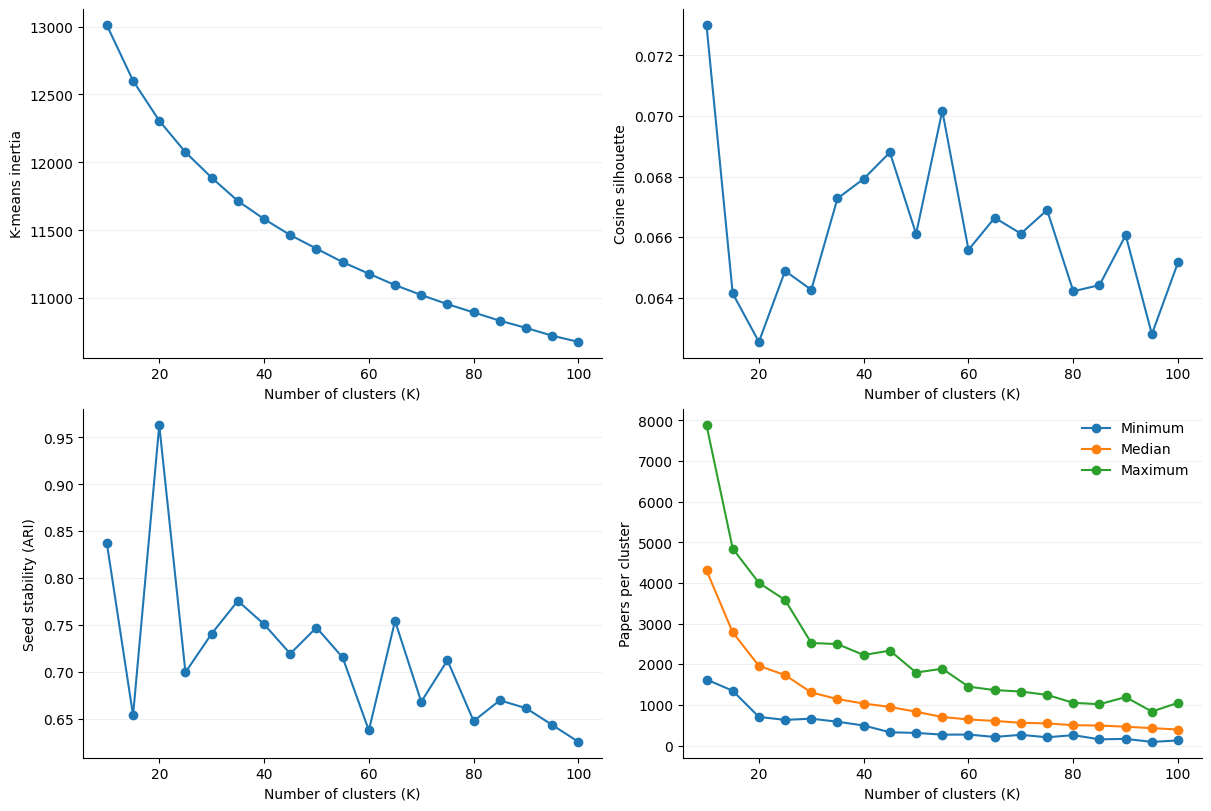

In [11]:
k_scan_path = (
    PROCESSED_DATA_DIR
    / "topic_analysis"
    / "kmeans_resolution_scan.csv"
)

if RUN_K_SCAN:
    from sklearn.cluster import KMeans
    from sklearn.metrics import adjusted_rand_score, silhouette_score
    from sklearn.preprocessing import normalize

    embedding_matrix = normalize(
        np.asarray(
            np.load(existing_embedding_path, mmap_mode="r"),
            dtype=np.float32,
        ),
        norm="l2",
    ).astype(np.float32)
    rng = np.random.default_rng(42)
    silhouette_rows = np.sort(
        rng.choice(
            len(embedding_matrix),
            min(10_000, len(embedding_matrix)),
            replace=False,
        )
    )
    scan_rows = []
    for k in range(10, 101, 5):
        primary_model = KMeans(
            n_clusters=k, n_init=20, max_iter=500, random_state=42
        ).fit(embedding_matrix)
        primary = primary_model.labels_
        secondary = KMeans(
            n_clusters=k, n_init=20, max_iter=500, random_state=43
        ).fit_predict(embedding_matrix)
        counts = np.bincount(primary)
        scan_rows.append(
            {
                "k": k,
                "inertia": float(primary_model.inertia_),
                "silhouette_cosine": float(
                    silhouette_score(
                        embedding_matrix[silhouette_rows],
                        primary[silhouette_rows],
                        metric="cosine",
                    )
                ),
                "seed_ari_42_43": float(
                    adjusted_rand_score(primary, secondary)
                ),
                "min_cluster_n": int(counts.min()),
                "p10_cluster_n": float(np.percentile(counts, 10)),
                "median_cluster_n": float(np.median(counts)),
                "max_cluster_n": int(counts.max()),
                "largest_cluster_share": float(counts.max() / len(primary)),
            }
        )
        print(f"Completed K={k}")
    k_scan = pd.DataFrame(scan_rows)
    k_scan["inertia_relative_drop"] = k_scan["inertia"].pct_change().mul(-1)
    k_scan_path.parent.mkdir(parents=True, exist_ok=True)
    k_scan.to_csv(k_scan_path, index=False, encoding="utf-8-sig")
else:
    if not k_scan_path.exists():
        raise FileNotFoundError(
            f"Missing cached K-resolution scan: {k_scan_path}. "
            "Set RUN_K_SCAN=True to reconstruct it."
        )
    k_scan = pd.read_csv(k_scan_path, encoding="utf-8-sig")
    print(f"Reusing candidate-K diagnostics: {k_scan_path}")

required_scan_columns = {
    "k", "inertia", "silhouette_cosine", "seed_ari_42_43",
    "min_cluster_n", "median_cluster_n", "max_cluster_n",
    "largest_cluster_share", "inertia_relative_drop",
}
missing_scan_columns = required_scan_columns - set(k_scan.columns)
if missing_scan_columns:
    raise KeyError(
        f"K-resolution scan is missing columns: {sorted(missing_scan_columns)}"
    )
k_scan = k_scan.sort_values("k").reset_index(drop=True)
display(k_scan)
print(f"Candidate resolutions evaluated: {k_scan['k'].tolist()}")
print(f"Saved/loaded diagnostic: {k_scan_path.relative_to(REPO_ROOT)}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
axes[0, 0].plot(k_scan["k"], k_scan["inertia"], marker="o")
axes[0, 0].set(xlabel="Number of clusters (K)", ylabel="K-means inertia")
axes[0, 1].plot(
    k_scan["k"], k_scan["silhouette_cosine"], marker="o"
)
axes[0, 1].set(
    xlabel="Number of clusters (K)", ylabel="Cosine silhouette"
)
axes[1, 0].plot(
    k_scan["k"], k_scan["seed_ari_42_43"], marker="o"
)
axes[1, 0].set(
    xlabel="Number of clusters (K)", ylabel="Seed stability (ARI)"
)
axes[1, 1].plot(
    k_scan["k"], k_scan["min_cluster_n"], marker="o", label="Minimum"
)
axes[1, 1].plot(
    k_scan["k"], k_scan["median_cluster_n"], marker="o", label="Median"
)
axes[1, 1].plot(
    k_scan["k"], k_scan["max_cluster_n"], marker="o", label="Maximum"
)
axes[1, 1].set(
    xlabel="Number of clusters (K)", ylabel="Papers per cluster"
)
axes[1, 1].legend(frameon=False)
for axis in axes.flat:
    axis.spines[["top", "right"]].set_visible(False)
    axis.grid(axis="y", alpha=0.2)
plt.show()

## Select the final topic clustering resolution

In [12]:
# This value records the decision made after reviewing the table above.
# It is deliberately defined here—not in the initial configuration—so
# subsequent code consumes the selected resolution instead of assuming it.
SELECTED_REPRESENTATION = "raw_l2_normalized_bge"
SELECTED_K = 55

selected_diagnostic = k_scan.loc[k_scan["k"].eq(SELECTED_K)].copy()
if len(selected_diagnostic) != 1:
    raise ValueError(
        f"Expected one diagnostic row for selected K={SELECTED_K}, "
        f"found {len(selected_diagnostic)}."
    )
display(selected_diagnostic)
print(f"Selected representation: {SELECTED_REPRESENTATION}")
print(f"Selected number of clusters after diagnostic review: K={SELECTED_K}")

,representation,k,inertia,silhouette_cosine,seed_ari_42_43,min_cluster_n,p10_cluster_n,median_cluster_n,max_cluster_n,largest_cluster_share,inertia_relative_drop
9,raw,55,11266.151367,0.070172,0.715309,269,412.6,704.0,1891,0.043602,0.008732


Selected representation: raw_l2_normalized_bge
Selected number of clusters after diagnostic review: K=55


# Fit the selected topic solution


In [13]:
if RUN_FINAL_CLUSTERING:
    from sklearn.cluster import KMeans
    from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
    from sklearn.preprocessing import normalize

    if not embedding_corpus_path.exists():
        raise FileNotFoundError("Filtered abstract corpus is unavailable.")
    corpus = pd.read_csv(
        embedding_corpus_path, encoding="utf-8-sig", low_memory=False
    )
    embedding_matrix = normalize(
        np.asarray(
            np.load(existing_embedding_path, mmap_mode="r"),
            dtype=np.float32,
        ),
        norm="l2",
    ).astype(np.float32)
    embedding_ids = np.load(
        existing_embedding_ids_path, allow_pickle=False
    ).astype(str)
    if len(corpus) != len(embedding_matrix):
        raise ValueError("Abstract and embedding row counts differ.")
    if not np.array_equal(corpus["id"].astype(str).to_numpy(), embedding_ids):
        raise ValueError("Abstract IDs do not match embedding row order.")

    model = KMeans(
        n_clusters=SELECTED_K,
        n_init=50,
        max_iter=500,
        random_state=42,
    )
    labels = model.fit_predict(embedding_matrix)
    corpus["topic"] = labels
    corpus["detector_positive"] = (
        pd.to_numeric(corpus["finetuned_decision"], errors="coerce")
        .eq(0)
        .astype("int8")
    )

    generic_terms = {
        "paper", "propose", "proposed", "method", "methods",
        "approach", "approaches", "result", "results", "show",
        "shows", "demonstrate", "demonstrates", "experiment",
        "experiments", "evaluate", "evaluation", "novel", "model",
        "models", "network", "networks", "data", "dataset",
        "datasets", "algorithm", "algorithms", "task", "tasks",
        "performance", "learning", "training", "feature", "features",
        "using", "based", "work", "problem", "problems", "framework",
        "frameworks", "system", "systems", "application",
        "applications", "effective", "improve", "improves", "improved",
        "existing", "design", "study", "studies",
    }
    vectorizer = CountVectorizer(
        stop_words=sorted(ENGLISH_STOP_WORDS.union(generic_terms)),
        min_df=3,
        max_df=0.8,
        ngram_range=(1, 3),
        max_features=100_000,
    )
    term_matrix = vectorizer.fit_transform(corpus["abstract"].astype(str))
    terms = vectorizer.get_feature_names_out()
    total_counts = np.asarray(term_matrix.sum(axis=0)).ravel()
    keyword_rows = []
    representative_rows = []
    for topic in range(SELECTED_K):
        rows = np.flatnonzero(labels == topic)
        within_counts = np.asarray(term_matrix[rows].sum(axis=0)).ravel()
        within_frequency = within_counts / max(within_counts.sum(), 1)
        outside_frequency = (total_counts - within_counts) / max(
            (total_counts - within_counts).sum(), 1
        )
        score = within_frequency * np.log(
            (within_frequency + 1e-12) / (outside_frequency + 1e-12)
        )
        top = [
            index
            for index in np.argsort(score)[::-1]
            if within_counts[index] > 0
        ][:12]
        centroid = embedding_matrix[rows].mean(axis=0)
        distance = np.linalg.norm(embedding_matrix[rows] - centroid, axis=1)
        keyword_rows.append(
            {
                "topic": topic,
                "n_papers": len(rows),
                "provisional_label": " / ".join(terms[top[:3]]),
                "top_keywords": ", ".join(terms[top]),
            }
        )
        for rank, position in enumerate(np.argsort(distance)[:10], start=1):
            record = corpus.iloc[rows[position]]
            representative_rows.append(
                {
                    "topic": topic,
                    "representative_rank": rank,
                    "id": record["id"],
                    "Year": record["Year"],
                    "Conference": record["Conference"],
                    "title": record["title"],
                    "abstract": record["abstract"],
                    "distance_to_centroid": float(distance[position]),
                }
            )

    rebuild_dir = (
        PROCESSED_DATA_DIR
        / "topic_analysis"
        / f"rebuild_k{SELECTED_K}"
    )
    rebuild_dir.mkdir(parents=True, exist_ok=True)
    corpus[
        ["id", "Conference", "Year", "topic", "detector_positive"]
    ].to_csv(
        rebuild_dir / "paper_topic_assignments.csv",
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(keyword_rows).to_csv(
        rebuild_dir / "topic_keywords.csv",
        index=False,
        encoding="utf-8-sig",
    )
    pd.DataFrame(representative_rows).to_csv(
        rebuild_dir / "topic_representative_abstracts.csv",
        index=False,
        encoding="utf-8-sig",
    )
    print(f"Rebuilt staged K={SELECTED_K} outputs in: {rebuild_dir}")
    print(pd.Series(labels).value_counts().describe().to_string())
else:
    print(f"[SKIP] Final K={SELECTED_K} clustering is disabled.")
    print("The reviewed topic assignments are loaded after the naming stage below.")

[SKIP] Final K=55 clustering is disabled.
The reviewed topic assignments are loaded after the naming stage below.


## LLM-assisted topic naming and broad semantic classification

Topic names and broad semantic categories are assigned only after the
selected detector-blind clustering solution is complete. For each cluster, the naming
prompt receives its cluster-specific keywords and representative
abstracts and asks an LLM to produce a concise descriptive topic name.
A second prompt receives the reviewed fine-grained topics and their
keywords and assigns each topic to one broad semantic research category.

Detector-positive rates are not provided to either prompt. The generated
names and category assignments are manually checked against the keywords
and representative papers. The complete prompt templates are documented
in the manuscript supplement. After review, the cluster assignments are
stored in `paper_topic_assignments.csv`, while the names, keywords, and
semantic-category labels are stored in `topic_definitions.csv`. These
reviewed files form the inputs to the analyses below.

In [14]:
# Topic-analysis variables are defined only after clustering, naming,
# semantic categorisation, and manual review have been completed.
EXPECTED_TOPICS = SELECTED_K
EXPECTED_CATEGORIES = 9
REFERENCE_CATEGORY = "Machine Learning Theory and Optimization"

TOPIC_PROCESSED_DIR = PROCESSED_DATA_DIR / "topic_analysis"
ASSIGNMENTS_CSV = TOPIC_PROCESSED_DIR / "paper_topic_assignments.csv"
DEFINITIONS_CSV = TOPIC_PROCESSED_DIR / "topic_definitions.csv"
SOURCE_DIR = REPO_ROOT / "data" / "source_data" / "06_topic_analysis"
SOURCE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Reviewed assignments: {ASSIGNMENTS_CSV}")
print(f"Reviewed topic definitions: {DEFINITIONS_CSV}")
print(f"Analysis source-data directory: {SOURCE_DIR}")
print(f"Expected fine-grained topics: {EXPECTED_TOPICS}")
print(f"Expected broad semantic categories: {EXPECTED_CATEGORIES}")

if RUN_FROM_SCRATCH:
    rebuilt_assignments_csv = (
        TOPIC_PROCESSED_DIR
        / f"rebuild_k{SELECTED_K}"
        / "paper_topic_assignments.csv"
    )
    if not rebuilt_assignments_csv.exists():
        raise FileNotFoundError(
            f"Expected rebuilt assignments at {rebuilt_assignments_csv}."
        )
    rebuilt_assignments = pd.read_csv(
        rebuilt_assignments_csv,
        usecols=["id", "topic"],
        encoding="utf-8-sig",
    )
    reviewed_assignments = pd.read_csv(
        ASSIGNMENTS_CSV,
        usecols=["id", "topic"],
        encoding="utf-8-sig",
    )
    comparison = rebuilt_assignments.merge(
        reviewed_assignments,
        on="id",
        how="outer",
        suffixes=("_rebuilt", "_reviewed"),
        indicator=True,
        validate="one_to_one",
    )
    same_assignment = (
        comparison["_merge"].eq("both")
        & comparison["topic_rebuilt"].eq(comparison["topic_reviewed"])
    )
    if not same_assignment.all():
        raise ValueError(
            "The rebuilt clustering differs from the reviewed assignment "
            "file. Repeat the LLM naming/category review for the rebuilt "
            "solution before running downstream analyses."
        )
    print("Rebuilt assignments exactly match the reviewed K solution.")

Reviewed assignments: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/topic_analysis/paper_topic_assignments.csv
Reviewed topic definitions: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/processed/topic_analysis/topic_definitions.csv
Analysis source-data directory: /home/user/GSK/lily/science_of_science/NewDataset/llm_impact_on_ai_pub/data/source_data/06_topic_analysis
Expected fine-grained topics: 55
Expected broad semantic categories: 9


## Load and validate processed topic assignments

In [15]:
assignments = pd.read_csv(
    ASSIGNMENTS_CSV, encoding="utf-8-sig", low_memory=False
)
definitions = pd.read_csv(
    DEFINITIONS_CSV, encoding="utf-8-sig", low_memory=False
)
required_assignment_columns = {
    "id", "Conference", "Year", "topic", "detector_positive"
}
required_definition_columns = {
    "topic", "n_papers", "top_keywords", "topic_name", "semantic_category"
}
missing_assignments = required_assignment_columns - set(assignments.columns)
missing_definitions = required_definition_columns - set(definitions.columns)
if missing_assignments:
    raise KeyError(f"Missing assignment columns: {sorted(missing_assignments)}")
if missing_definitions:
    raise KeyError(f"Missing definition columns: {sorted(missing_definitions)}")

assignments["Year"] = pd.to_numeric(assignments["Year"], errors="coerce")
assignments["topic"] = pd.to_numeric(assignments["topic"], errors="coerce")
assignments["detector_positive"] = pd.to_numeric(
    assignments["detector_positive"], errors="coerce"
)
definitions["topic"] = pd.to_numeric(definitions["topic"], errors="coerce")

if len(assignments) != EXPECTED_PAPERS:
    raise ValueError(
        f"Expected {EXPECTED_PAPERS:,} assignments, found {len(assignments):,}."
    )
if assignments["id"].duplicated().any():
    raise ValueError("Topic assignments contain duplicate paper IDs.")
if set(assignments["Year"].dropna().astype(int)) != set(ANALYSIS_YEARS):
    raise ValueError("Assignments must contain only 2024 and 2025 papers.")
if not assignments["detector_positive"].isin([0, 1]).all():
    raise ValueError("detector_positive must contain only 0 and 1.")
if assignments["topic"].nunique() != EXPECTED_TOPICS:
    raise ValueError(
        f"Expected exactly {EXPECTED_TOPICS} assigned topic clusters."
    )
if len(definitions) != EXPECTED_TOPICS or definitions["topic"].nunique() != EXPECTED_TOPICS:
    raise ValueError(
        f"Expected exactly {EXPECTED_TOPICS} unique topic definitions."
    )
if definitions[["topic_name", "semantic_category"]].isna().any().any():
    raise ValueError("Topic names or semantic categories are missing.")
if definitions["semantic_category"].nunique() != EXPECTED_CATEGORIES:
    raise ValueError("Expected exactly nine broad semantic categories.")
if REFERENCE_CATEGORY not in set(definitions["semantic_category"]):
    raise ValueError(f"Reference category is absent: {REFERENCE_CATEGORY}")

main = pd.read_csv(
    PAPERS_CSV,
    usecols=["id", "Conference", "Year", "finetuned_decision"],
    encoding="utf-8-sig",
    low_memory=False,
)
main["Year"] = pd.to_numeric(main["Year"], errors="coerce")
main["finetuned_decision"] = pd.to_numeric(
    main["finetuned_decision"], errors="coerce"
)
main = main.loc[main["Year"].isin(ANALYSIS_YEARS)].copy()
main["expected_detector_positive"] = main["finetuned_decision"].eq(0).astype(int)
check = assignments.merge(
    main[["id", "Conference", "Year", "expected_detector_positive"]],
    on="id",
    how="left",
    suffixes=("", "_main"),
    validate="one_to_one",
)
if check["Year_main"].isna().any():
    raise ValueError("Some topic-assigned papers are absent from id_papers.csv.")
if not check["Year"].eq(check["Year_main"]).all():
    raise ValueError("Publication years disagree with id_papers.csv.")
if not check["Conference"].astype(str).eq(check["Conference_main"].astype(str)).all():
    raise ValueError("Conference labels disagree with id_papers.csv.")
if not check["detector_positive"].eq(check["expected_detector_positive"]).all():
    raise ValueError("Detector-positive labels disagree with id_papers.csv.")

topic_counts = assignments.groupby("topic").size().rename("observed_n_papers")
definition_check = definitions.merge(
    topic_counts, on="topic", how="left", validate="one_to_one"
)
if not definition_check["n_papers"].eq(definition_check["observed_n_papers"]).all():
    raise ValueError("Topic-definition paper counts do not match assignments.")

print(f"Validated papers: {len(assignments):,}")
print(f"Validated fine-grained topics: {assignments['topic'].nunique()}")
print(f"Validated broad semantic categories: {definitions['semantic_category'].nunique()}")
display(
    assignments.groupby("Year", as_index=False).agg(
        n_papers=("id", "size"),
        n_detector_positive=("detector_positive", "sum"),
        detector_positive_rate=("detector_positive", "mean"),
    )
)

Validated papers: 43,370
Validated fine-grained topics: 55
Validated broad semantic categories: 9


,Year,n_papers,n_detector_positive,detector_positive_rate
0,2024,18789,5336,0.283996
1,2025,24581,13058,0.531223


## Confidence-interval helper

In [16]:
def wilson_interval(positive: int, total: int, alpha: float = 0.05):
    if total <= 0:
        return np.nan, np.nan
    z = norm.ppf(1 - alpha / 2)
    p = positive / total
    denominator = 1 + z**2 / total
    centre = (p + z**2 / (2 * total)) / denominator
    half_width = (
        z
        * np.sqrt(p * (1 - p) / total + z**2 / (4 * total**2))
        / denominator
    )
    return centre - half_width, centre + half_width


print("Wilson 95% confidence-interval helper ready.")

Wilson 95% confidence-interval helper ready.


## Fine-grained topic rates: construct source data

Pooled estimates combine 2024 and 2025. Annual estimates are retained
separately to show within-topic changes between the two years.

In [17]:
def summarize_binary_rate(frame: pd.DataFrame) -> pd.Series:
    total = len(frame)
    positive = int(frame["detector_positive"].sum())
    lower, upper = wilson_interval(positive, total)
    return pd.Series(
        {
            "n_papers": total,
            "n_detector_positive": positive,
            "detector_positive_rate": positive / total,
            "ci95_lower": lower,
            "ci95_upper": upper,
        }
    )


pooled_topic = (
    assignments.groupby("topic", as_index=False)
    .apply(summarize_binary_rate, include_groups=False)
    .reset_index(drop=True)
    .merge(
        definitions[["topic", "topic_name", "semantic_category", "top_keywords"]],
        on="topic",
        validate="one_to_one",
    )
)
pooled_topic["detector_positive_rate_percent"] = (
    100 * pooled_topic["detector_positive_rate"]
)
pooled_topic["ci95_lower_percent"] = 100 * pooled_topic["ci95_lower"]
pooled_topic["ci95_upper_percent"] = 100 * pooled_topic["ci95_upper"]
pooled_topic = pooled_topic.sort_values(
    "detector_positive_rate", ascending=False
).reset_index(drop=True)

annual_topic = (
    assignments.groupby(["topic", "Year"], as_index=False)
    .apply(summarize_binary_rate, include_groups=False)
    .reset_index(drop=True)
    .merge(
        definitions[["topic", "topic_name", "semantic_category"]],
        on="topic",
        validate="many_to_one",
    )
)
annual_topic["detector_positive_rate_percent"] = (
    100 * annual_topic["detector_positive_rate"]
)
annual_topic["ci95_lower_percent"] = 100 * annual_topic["ci95_lower"]
annual_topic["ci95_upper_percent"] = 100 * annual_topic["ci95_upper"]

change = annual_topic.pivot(
    index=["topic", "topic_name", "semantic_category"],
    columns="Year",
    values=["n_papers", "detector_positive_rate_percent"],
)
change.columns = [f"{metric}_{int(year)}" for metric, year in change.columns]
change = change.reset_index()
change["change_pp_2025_minus_2024"] = (
    change["detector_positive_rate_percent_2025"]
    - change["detector_positive_rate_percent_2024"]
)
change["eligible_30_papers_each_year"] = (
    change["n_papers_2024"].ge(30) & change["n_papers_2025"].ge(30)
)
change = change.sort_values(
    "change_pp_2025_minus_2024", ascending=False
).reset_index(drop=True)

pooled_path = SOURCE_DIR / "topic_pooled_rates.csv"
annual_path = SOURCE_DIR / "topic_year_rates.csv"
change_path = SOURCE_DIR / "topic_2024_2025_changes.csv"
pooled_topic.to_csv(pooled_path, index=False, encoding="utf-8-sig")
annual_topic.to_csv(annual_path, index=False, encoding="utf-8-sig")
change.to_csv(change_path, index=False, encoding="utf-8-sig")

print(f"Saved: {pooled_path.relative_to(REPO_ROOT)}")
print(f"Saved: {annual_path.relative_to(REPO_ROOT)}")
print(f"Saved: {change_path.relative_to(REPO_ROOT)}")
display(
    pooled_topic[
        [
            "topic", "topic_name", "n_papers", "n_detector_positive",
            "detector_positive_rate_percent", "ci95_lower_percent",
            "ci95_upper_percent",
        ]
    ]
)

Saved: data/source_data/06_topic_analysis/topic_pooled_rates.csv
Saved: data/source_data/06_topic_analysis/topic_year_rates.csv
Saved: data/source_data/06_topic_analysis/topic_2024_2025_changes.csv


,topic,topic_name,n_papers,n_detector_positive,detector_positive_rate_percent,ci95_lower_percent,ci95_upper_percent
0,17,Clinical AI and Electronic Health Records,573.0,328.0,57.242583,53.156817,61.231885
1,4,Medical Image Segmentation and Analysis,596.0,337.0,56.543624,52.534622,60.468813
2,52,LLM Agents and Multi-Agent Planning,947.0,527.0,55.649419,52.468790,58.784401
3,36,Protein and Molecular Representation Learning,614.0,328.0,53.420195,49.465536,57.332324
4,15,Text-to-SQL and Table Understanding,269.0,141.0,52.416357,46.456327,58.308345
5,35,Vision-Language Models and Multimodal Reasoning,1265.0,662.0,52.332016,49.576790,55.073122
6,8,Human Preference Optimization for LLM Alignment,585.0,305.0,52.136752,48.087989,56.157636
7,26,Time Series Forecasting,666.0,345.0,51.801802,48.007465,55.575472
8,28,LLM Efficient Fine-Tuning and Inference Optimi...,1327.0,682.0,51.394122,48.704837,54.075359
9,48,Hallucination Detection in Vision-Language Models,296.0,151.0,51.013514,45.342252,56.658805


## Fine-grained topic forest plot

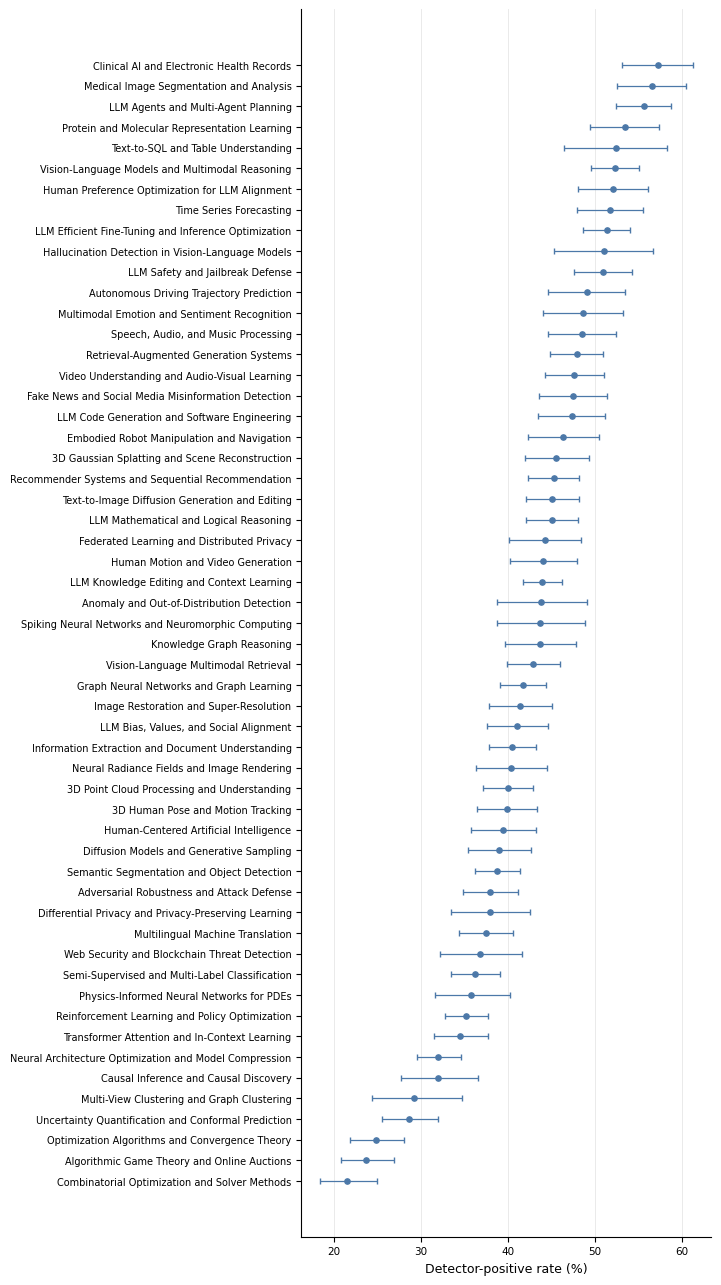

Displayed pooled fine-grained topic forest plot from topic_pooled_rates.csv.


In [18]:
mpl.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
        "font.size": 8,
        "axes.labelsize": 9,
        "xtick.labelsize": 7.5,
        "ytick.labelsize": 7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 0.8,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
    }
)

topic_plot = pd.read_csv(
    SOURCE_DIR / "topic_pooled_rates.csv", encoding="utf-8-sig"
).sort_values("detector_positive_rate_percent", ascending=True)
y = np.arange(len(topic_plot))
estimate = topic_plot["detector_positive_rate_percent"].to_numpy(float)
lower = topic_plot["ci95_lower_percent"].to_numpy(float)
upper = topic_plot["ci95_upper_percent"].to_numpy(float)

fig, ax = plt.subplots(figsize=(8.2, 13.2))
ax.errorbar(
    estimate,
    y,
    xerr=np.vstack([estimate - lower, upper - estimate]),
    fmt="o",
    color="#4C78A8",
    ecolor="#4C78A8",
    markersize=3.8,
    elinewidth=0.9,
    capsize=2,
)
ax.set_yticks(y)
ax.set_yticklabels(topic_plot["topic_name"])
ax.set_xlabel("Detector-positive rate (%)")
ax.grid(axis="x", color="#E6E6E6", linewidth=0.6)
ax.set_axisbelow(True)
fig.subplots_adjust(left=0.48, right=0.98, bottom=0.06, top=0.99)
plt.show()
plt.close(fig)
print("Displayed pooled fine-grained topic forest plot from topic_pooled_rates.csv.")

## Within-topic change from 2024 to 2025

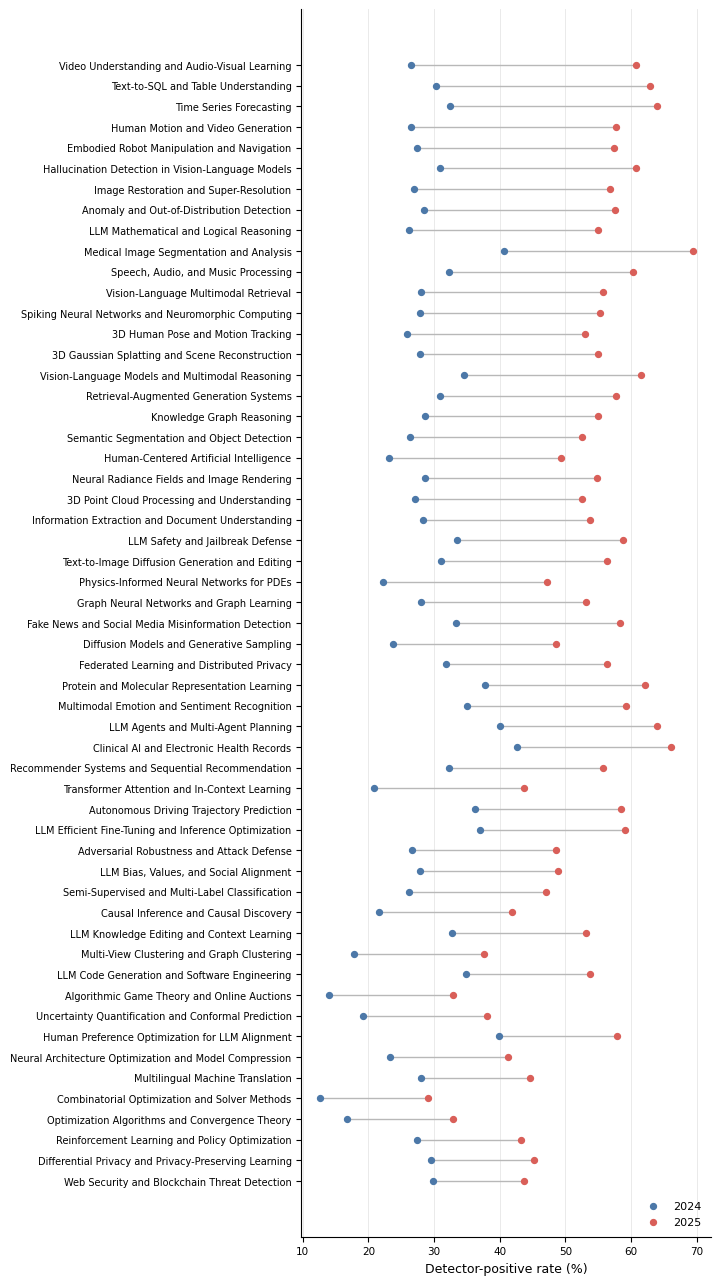

Displayed 2024–2025 topic dumbbell plot from topic_2024_2025_changes.csv.


In [19]:
change_plot = pd.read_csv(
    SOURCE_DIR / "topic_2024_2025_changes.csv", encoding="utf-8-sig"
).sort_values("change_pp_2025_minus_2024", ascending=True)
y = np.arange(len(change_plot))
rate_2024 = change_plot["detector_positive_rate_percent_2024"].to_numpy(float)
rate_2025 = change_plot["detector_positive_rate_percent_2025"].to_numpy(float)

fig, ax = plt.subplots(figsize=(8.2, 13.2))
for yi, left, right in zip(y, rate_2024, rate_2025):
    ax.plot([left, right], [yi, yi], color="#B8B8B8", linewidth=1.0, zorder=1)
ax.scatter(rate_2024, y, s=18, color="#4C78A8", label="2024", zorder=2)
ax.scatter(rate_2025, y, s=18, color="#D95F59", label="2025", zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(change_plot["topic_name"])
ax.set_xlabel("Detector-positive rate (%)")
ax.grid(axis="x", color="#E6E6E6", linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="lower right", frameon=False)
fig.subplots_adjust(left=0.48, right=0.98, bottom=0.06, top=0.99)
plt.show()
plt.close(fig)
print("Displayed 2024–2025 topic dumbbell plot from topic_2024_2025_changes.csv.")

## Broad semantic-category prevalence

Category-level rates pool papers across all fine-grained topics assigned
to each of the nine reviewed semantic categories. Error bars use Wilson
binomial intervals.

In [20]:
assignments_with_category = assignments.merge(
    definitions[["topic", "semantic_category"]],
    on="topic",
    validate="many_to_one",
)
category_prevalence = (
    assignments_with_category.groupby("semantic_category", as_index=False)
    .apply(summarize_binary_rate, include_groups=False)
    .reset_index(drop=True)
)
cluster_counts = (
    definitions.groupby("semantic_category")["topic"]
    .nunique()
    .rename("n_topic_clusters")
)
category_prevalence = category_prevalence.merge(
    cluster_counts, on="semantic_category", validate="one_to_one"
)
category_prevalence["detector_positive_rate_percent"] = (
    100 * category_prevalence["detector_positive_rate"]
)
category_prevalence["ci95_lower_percent"] = (
    100 * category_prevalence["ci95_lower"]
)
category_prevalence["ci95_upper_percent"] = (
    100 * category_prevalence["ci95_upper"]
)
category_prevalence = category_prevalence.sort_values(
    "detector_positive_rate", ascending=False
).reset_index(drop=True)
category_path = SOURCE_DIR / "category_prevalence.csv"
category_prevalence.to_csv(
    category_path, index=False, encoding="utf-8-sig"
)
print(f"Saved: {category_path.relative_to(REPO_ROOT)}")
display(category_prevalence)

Saved: data/source_data/06_topic_analysis/category_prevalence.csv


,semantic_category,n_papers,n_detector_positive,detector_positive_rate,ci95_lower,ci95_upper,n_topic_clusters,detector_positive_rate_percent,ci95_lower_percent,ci95_upper_percent
0,AI for Healthcare and Science,1783.0,993.0,0.556927,0.533771,0.579837,3,55.692653,53.377128,57.983701
1,Speech and Audio Intelligence,637.0,309.0,0.485086,0.446481,0.523870,1,48.508634,44.648111,52.387037
2,Embodied AI and Autonomous Systems,1055.0,502.0,0.475829,0.445836,0.505998,2,47.582938,44.583579,50.599836
3,Large Language Models and Generative AI,12330.0,5773.0,0.468208,0.459411,0.477024,13,46.820762,45.941131,47.702374
4,Human-Centered AI and Applications,1109.0,479.0,0.431921,0.403052,0.461260,2,43.192065,40.305169,46.125961
5,Natural Language Processing and Knowledge,4136.0,1751.0,0.423356,0.408376,0.438478,5,42.335590,40.837593,43.847810
6,Computer Vision and Multimodal Intelligence,7126.0,2981.0,0.418327,0.406921,0.429821,8,41.832725,40.692117,42.982134
7,"AI Safety, Security and Trust",5671.0,2326.0,0.410157,0.397420,0.423015,9,41.015694,39.742043,42.301509
8,Machine Learning Theory and Optimization,9523.0,3280.0,0.344429,0.334950,0.354034,12,34.442928,33.494993,35.403408


## Semantic-category prevalence figure

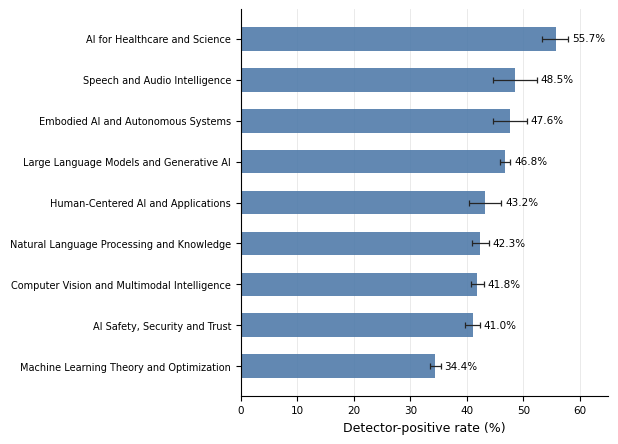

Displayed semantic-category prevalence figure from category_prevalence.csv.


In [21]:
category_plot = pd.read_csv(
    SOURCE_DIR / "category_prevalence.csv", encoding="utf-8-sig"
)
y = np.arange(len(category_plot))
value = category_plot["detector_positive_rate_percent"].to_numpy(float)
lower = category_plot["ci95_lower_percent"].to_numpy(float)
upper = category_plot["ci95_upper_percent"].to_numpy(float)

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.barh(y, value, height=0.58, color="#4C78A8", alpha=0.88)
ax.errorbar(
    value,
    y,
    xerr=np.vstack([value - lower, upper - value]),
    fmt="none",
    ecolor="#252525",
    elinewidth=0.9,
    capsize=2.5,
    capthick=0.9,
    zorder=3,
)
for yi, estimate, high in zip(y, value, upper):
    ax.text(high + 0.65, yi, f"{estimate:.1f}%", va="center", fontsize=7.5)
ax.set_yticks(y)
ax.set_yticklabels(category_plot["semantic_category"])
ax.invert_yaxis()
ax.set_xlim(0, max(upper) + 7)
ax.set_xlabel("Detector-positive rate (%)")
ax.grid(axis="x", color="#E6E6E6", linewidth=0.6)
ax.set_axisbelow(True)
fig.subplots_adjust(left=0.47, right=0.98, bottom=0.13, top=0.97)
plt.show()
plt.close(fig)
print("Displayed semantic-category prevalence figure from category_prevalence.csv.")

## Venue-adjusted cluster-level binomial regression

The selected fine-grained topic clusters are the analysis units. For cluster
$i$, the detector-positive count is modelled as
$Y_i \sim \mathrm{Binomial}(N_i,p_i)$. Predictors include broad semantic
category and the conference proportions of the cluster. Because the ten
conference proportions sum to one, the conference with the largest
paper count is omitted. Machine Learning Theory and Optimization is the
prespecified semantic reference category. HC3 heteroskedasticity-robust
standard errors treat the selected topic clusters as independent observations.
Benjamini–Hochberg correction is applied across the eight non-reference
category contrasts.

In [22]:
def safe_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9]+", "_", str(value)).strip("_")


cluster_counts = (
    assignments.groupby("topic", as_index=False)
    .agg(
        total_papers=("detector_positive", "size"),
        detector_positive_count=("detector_positive", "sum"),
    )
)
venue_counts = pd.crosstab(assignments["topic"], assignments["Conference"])
venues = sorted(venue_counts.columns.astype(str))
venue_counts = venue_counts.reindex(columns=venues, fill_value=0)
venue_proportions = venue_counts.div(venue_counts.sum(axis=1), axis=0)
venue_proportions.columns = [
    f"venue_prop__{safe_name(column)}" for column in venue_proportions.columns
]
venue_proportions = venue_proportions.reset_index()

cluster_model_data = (
    definitions[["topic", "topic_name", "semantic_category"]]
    .merge(cluster_counts, on="topic", validate="one_to_one")
    .merge(venue_proportions, on="topic", validate="one_to_one")
)
cluster_model_data["detector_positive_rate"] = (
    cluster_model_data["detector_positive_count"]
    / cluster_model_data["total_papers"]
)
if len(cluster_model_data) != EXPECTED_TOPICS:
    raise ValueError(
        f"Cluster-level regression must contain {EXPECTED_TOPICS} observations."
    )
if not (
    cluster_model_data["detector_positive_count"]
    <= cluster_model_data["total_papers"]
).all():
    raise ValueError("Detector-positive counts exceed cluster totals.")

categories = [REFERENCE_CATEGORY] + sorted(
    category
    for category in cluster_model_data["semantic_category"].unique()
    if category != REFERENCE_CATEGORY
)
design = pd.DataFrame(
    {"Intercept": np.ones(len(cluster_model_data))},
    index=cluster_model_data.index,
)
category_columns = []
for category in categories[1:]:
    column = f"Category::{category}"
    design[column] = cluster_model_data["semantic_category"].eq(category).astype(float)
    category_columns.append(column)

venue_columns = [
    column for column in cluster_model_data if column.startswith("venue_prop__")
]
venue_totals = {
    column: float(
        (cluster_model_data[column] * cluster_model_data["total_papers"]).sum()
    )
    for column in venue_columns
}
venue_reference = max(venue_totals, key=venue_totals.get)
for column in venue_columns:
    if column != venue_reference:
        design[column] = cluster_model_data[column].astype(float)

endog = np.column_stack(
    [
        cluster_model_data["detector_positive_count"].to_numpy(),
        (
            cluster_model_data["total_papers"]
            - cluster_model_data["detector_positive_count"]
        ).to_numpy(),
    ]
)
model = sm.GLM(endog, design, family=sm.families.Binomial())
result = model.fit(cov_type="HC3", maxiter=1_000)
if not result.converged:
    raise RuntimeError("Venue-adjusted binomial GLM did not converge.")

restriction = np.zeros((len(category_columns), len(result.params)))
for row, column in enumerate(category_columns):
    restriction[row, list(design.columns).index(column)] = 1
omnibus = result.wald_test(restriction, scalar=True)

association_rows = [
    {
        "semantic_category": REFERENCE_CATEGORY,
        "coefficient": 0.0,
        "standard_error": np.nan,
        "odds_ratio": 1.0,
        "ci95_lower": 1.0,
        "ci95_upper": 1.0,
        "p_value": np.nan,
        "fdr_adjusted_p": np.nan,
        "fdr_significant_0_05": False,
        "reference": True,
    }
]
nonreference_rows = []
for category, column in zip(categories[1:], category_columns):
    beta = float(result.params[column])
    standard_error = float(result.bse[column])
    nonreference_rows.append(
        {
            "semantic_category": category,
            "coefficient": beta,
            "standard_error": standard_error,
            "odds_ratio": float(np.exp(beta)),
            "ci95_lower": float(np.exp(beta - 1.96 * standard_error)),
            "ci95_upper": float(np.exp(beta + 1.96 * standard_error)),
            "p_value": float(result.pvalues[column]),
            "reference": False,
        }
    )
adjusted = multipletests(
    [row["p_value"] for row in nonreference_rows], method="fdr_bh"
)[1]
for row, adjusted_p in zip(nonreference_rows, adjusted):
    row["fdr_adjusted_p"] = float(adjusted_p)
    row["fdr_significant_0_05"] = bool(adjusted_p < 0.05)
association_rows.extend(nonreference_rows)
associations = pd.DataFrame(association_rows)

sizes = (
    cluster_model_data.groupby("semantic_category", as_index=False)
    .agg(
        n_topic_clusters=("topic", "size"),
        n_papers=("total_papers", "sum"),
        n_detector_positive=("detector_positive_count", "sum"),
    )
)
associations = associations.merge(
    sizes, on="semantic_category", how="left", validate="one_to_one"
)
associations["observed_detector_positive_rate"] = (
    associations["n_detector_positive"] / associations["n_papers"]
)
associations["venue_reference"] = venue_reference.replace("venue_prop__", "")
associations["n_model_clusters"] = len(cluster_model_data)

model_input_path = SOURCE_DIR / "category_regression_cluster_input.csv"
association_path = SOURCE_DIR / "category_venue_adjusted_associations.csv"
metadata_path = SOURCE_DIR / "category_regression_metadata.csv"
cluster_model_data.to_csv(
    model_input_path, index=False, encoding="utf-8-sig"
)
associations.to_csv(
    association_path, index=False, encoding="utf-8-sig"
)
metadata = pd.DataFrame(
    [
        {
            "model": "cluster-level grouped binomial GLM",
            "n_topic_clusters": len(cluster_model_data),
            "n_papers": int(cluster_model_data["total_papers"].sum()),
            "n_semantic_categories": len(categories),
            "reference_category": REFERENCE_CATEGORY,
            "venue_reference": venue_reference.replace("venue_prop__", ""),
            "n_venue_composition_covariates": len(venue_columns) - 1,
            "covariance": "HC3 heteroskedasticity-robust",
            "category_omnibus_wald_chi_square": float(omnibus.statistic),
            "category_omnibus_df": len(category_columns),
            "category_omnibus_p_value": float(omnibus.pvalue),
            "pearson_dispersion": float(result.pearson_chi2 / result.df_resid),
            "converged": bool(result.converged),
        }
    ]
)
metadata.to_csv(metadata_path, index=False, encoding="utf-8-sig")

print(f"Saved: {model_input_path.relative_to(REPO_ROOT)}")
print(f"Saved: {association_path.relative_to(REPO_ROOT)}")
print(f"Saved: {metadata_path.relative_to(REPO_ROOT)}")
display(metadata)
display(associations.sort_values("odds_ratio", ascending=False))

Saved: data/source_data/06_topic_analysis/category_regression_cluster_input.csv
Saved: data/source_data/06_topic_analysis/category_venue_adjusted_associations.csv
Saved: data/source_data/06_topic_analysis/category_regression_metadata.csv


,model,n_topic_clusters,n_papers,n_semantic_categories,reference_category,venue_reference,n_venue_composition_covariates,covariance,category_omnibus_wald_chi_square,category_omnibus_df,category_omnibus_p_value,pearson_dispersion,converged
0,cluster-level grouped binomial GLM,55,43370,9,Machine Learning Theory and Optimization,CVPR,9,HC3 heteroskedasticity-robust,53.75023,8,7.717881e-09,7.798874,True


,semantic_category,coefficient,standard_error,odds_ratio,ci95_lower,ci95_upper,p_value,fdr_adjusted_p,fdr_significant_0_05,reference,n_topic_clusters,n_papers,n_detector_positive,observed_detector_positive_rate,venue_reference,n_model_clusters
2,AI for Healthcare and Science,0.643391,0.113327,1.902923,1.523895,2.376225,1.368546e-08,1.094837e-07,True,False,3,1783,993,0.556927,CVPR,55
8,Speech and Audio Intelligence,0.451611,1.379976,1.570840,0.105069,23.485031,7.434714e-01,8.496816e-01,False,False,1,637,309,0.485086,CVPR,55
5,Human-Centered AI and Applications,0.276755,0.290825,1.318843,0.745826,2.332108,3.412900e-01,6.542949e-01,False,False,2,1109,479,0.431921,CVPR,55
6,Large Language Models and Generative AI,0.228311,0.283992,1.256477,0.720138,2.192264,4.214333e-01,6.542949e-01,False,False,13,12330,5773,0.468208,CVPR,55
4,Embodied AI and Autonomous Systems,0.208674,0.123298,1.232043,0.967548,1.568844,9.056370e-02,3.622548e-01,False,False,2,1055,502,0.475829,CVPR,55
3,Computer Vision and Multimodal Intelligence,0.135746,0.184136,1.145391,0.798388,1.643212,4.609976e-01,6.542949e-01,False,False,8,7126,2981,0.418327,CVPR,55
1,"AI Safety, Security and Trust",0.122037,0.177080,1.129796,0.798484,1.598577,4.907212e-01,6.542949e-01,False,False,9,5671,2326,0.410157,CVPR,55
0,Machine Learning Theory and Optimization,0.000000,NaN,1.000000,1.000000,1.000000,NaN,NaN,False,True,12,9523,3280,0.344429,CVPR,55
7,Natural Language Processing and Knowledge,-0.014506,0.291477,0.985599,0.556660,1.745060,9.603082e-01,9.603082e-01,False,False,5,4136,1751,0.423356,CVPR,55


## Venue-adjusted association forest plot

Categories follow the same order as the prevalence figure. The reference
category has an odds ratio of one. Red points denote comparisons that
remain significant after Benjamini–Hochberg correction.

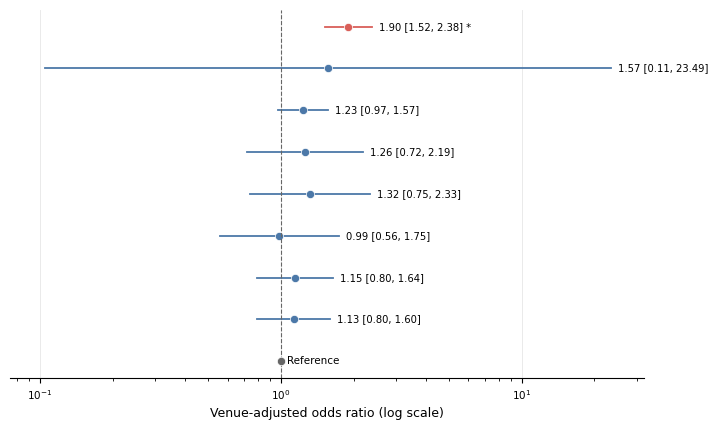

Displayed venue-adjusted semantic-category association forest plot.


In [23]:
category_order = pd.read_csv(
    SOURCE_DIR / "category_prevalence.csv", encoding="utf-8-sig"
)["semantic_category"].tolist()
association_plot = pd.read_csv(
    SOURCE_DIR / "category_venue_adjusted_associations.csv",
    encoding="utf-8-sig",
)
association_plot["semantic_category"] = pd.Categorical(
    association_plot["semantic_category"],
    categories=category_order,
    ordered=True,
)
association_plot = association_plot.sort_values("semantic_category").reset_index(drop=True)

y = np.arange(len(association_plot))
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for index, row in association_plot.iterrows():
    if bool(row["reference"]):
        ax.scatter(
            1.0, index, s=35, color="#666666", edgecolor="white",
            linewidth=0.5, zorder=3,
        )
        ax.text(1.06, index, "Reference", va="center", fontsize=7.5)
        continue
    significant = bool(row["fdr_significant_0_05"])
    color = "#D95F59" if significant else "#4C78A8"
    ax.plot(
        [row["ci95_lower"], row["ci95_upper"]],
        [index, index],
        color=color,
        linewidth=1.3,
        zorder=1,
    )
    ax.scatter(
        row["odds_ratio"], index, s=35, color=color,
        edgecolor="white", linewidth=0.5, zorder=2,
    )
    marker = " *" if significant else ""
    ax.text(
        row["ci95_upper"] * 1.07,
        index,
        f"{row['odds_ratio']:.2f} "
        f"[{row['ci95_lower']:.2f}, {row['ci95_upper']:.2f}]{marker}",
        va="center",
        fontsize=7.2,
    )

ax.axvline(1, color="#666666", linestyle="--", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlim(0.075, 32)
ax.set_yticks(y)
ax.invert_yaxis()
ax.tick_params(axis="y", which="both", left=False, labelleft=False)
ax.spines["left"].set_visible(False)
ax.set_xlabel("Venue-adjusted odds ratio (log scale)")
ax.grid(axis="x", color="#E6E6E6", linewidth=0.6)
ax.set_axisbelow(True)
fig.subplots_adjust(left=0.08, right=0.96, bottom=0.17, top=0.97)
plt.show()
plt.close(fig)
print("Displayed venue-adjusted semantic-category association forest plot.")